# Logistic Regression:

Is a GLM that uses for binary, multinomial, and multilabel classification tasks. We have two types of classification:
- Soft Classification
- Hard Classification

Logistic Regression can do soft classification cause it has a probability-like output and by choosing a threshold we hard classified the output label.

## Main Components:
- **Random Component:** Binomial Distribution
- **Systematic Component:** Linear Predictor
- **Link Function:** Logit Function

## Mathematics:

**The linear predictor:**

$ z = \omega_1x_1 + \omega_2x_2 + \omega_3x_3 + ... + \epsilon $

- **z** is the linear predictor output.
- **$\omega$** is the linear model's weight.
- **x** is the feature.

**The link function:**

$ \text{logit(p)} = ln(\frac{p}{1 - p}) = z $

--> $ \text{Sigmoid(z)} = \frac{1}{1 + \exp^{-z}} = p $

- **p** is the probability of success.

So in this model to expand the linear regression concept we assume the linear relationship between features and the log-odds of the output. **Assumption:** z - logit(p) --> is a linear relationship

In [52]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z: float) -> np.ndarray:
	"""Computes the Sigmoid function.

	:param z: Is the linear predictor output.
	:return: Is the probability of the success.
	"""
	return 1 / (1 + np.exp(-z))

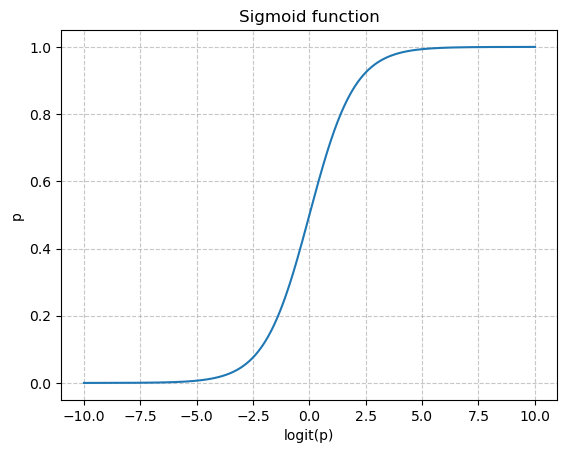

In [74]:
x = np.linspace(-10, 10, 1000)
y = sigmoid(x)

fig, ax = plt.subplots()

ax.plot(x, y)
ax.set(
    title="Sigmoid function",
    xlabel="logit(p)",
    ylabel="p"
)
ax.grid(True, linestyle="--", alpha=0.7)

> **Odds:** Is the rate of the probability of success with respect to the probability of failure.
>
> $ \text{Odds} = \frac{p}{1 - p}$

> **Log-Odds:** Log-odds is the logarithm of the odds of the probability.
>
> $ \text{Log-Odds} = \log(\frac{p}{1 - p}) $

These two concepts are import because of the interpretability of the Logistic Regression model. A coefficient of the Logistic Regression model shows the change of Log-Odds in the output.

> **Pro Tip:** think of the coefficients as the "*importance score*" for your features.

In [28]:
def odds(probability):
    return probability / (1 - probability)

def log_odds(probability):
    return np.log(odds(probability))

In [ ]:
# example:
# linear predictor output: 0.1
z = 0.1
p = sigmoid(z)
print(f"Probability: {p:.3f}")

odds_ = odds(p)
print(f"Odds: {odds_:.3f}")
# keeping all other coefficients unchange the odds of the succession for the output becomes 10.5
# percent more

log_odds_ = log_odds(p)
print(f"Log-Odds: {log_odds_}")

Probability: 0.525
Odds: 1.105
Log-Odds: 0.10000000000000007


## Cons & Pros:

**Advantages of the Logistic Regression Model:**

- Interpretability
- Simplicity
- Efficiency
- No Normality Assumption of errors
- Probability-like Output
- Handles Multi-Class Classification --> OVR, Softmax

**Disadvantages of the Logistic Regression Model:**

- Vulnerability to Outliers
- Assumes Linear Relationship
- Can't Capture complex Non-Linear Pattern --> use: Random Forest, Neural Networks, SVMs, ...
- Assumes Independence of Features
- Prone to Overfitting in High Dimensional Data

## Logistic Regression Model Code from Scratch:

In [88]:
# Coding model from scratch:
import numpy as np

# sigmoid function
def sigmoid(z: float) -> np.ndarray:
    """Computes the sigmoid function.

	:param z: output of the linear predictor
	:return: the probability like output of the sigmoid function
	"""
    return 1 / (1 + np.exp(-z)) 

# gradient of the cost funtion (MLE)
def compute_gradient_logistic(
          X: np.ndarray, y:np.ndarray, beta:np.ndarray
) -> np.ndarray:
    """Computes the gradient of log-likelihood with respect to beta.

	:param X: Features. (Add intercept if needed)
	:param y: Target variable.
	:param beta: Weights array.
	:return: The gradient of the log-likelihood with respect to beta.
	"""
    n = X.shape[0]
    p = sigmoid(X @ beta) # probability for each sample
    return (1 / n) * X.T @ (p - y) # dim: n*1

# Defining the cost function (MLE)
def compute_cost_logistic(X, y, beta):
    """Computes the cost of the model in the optimization process.

	:param X: Features. (Add intercept if needed)
	:param y: Target variable.
	:param beta: Weights array.
	:return: The cost of the model.
	"""
    n = X.shape[0]
    p = sigmoid(X @ beta)
    return -np.sum(y * np.log(p) + (1 - y) * np.log(1 - p)) / n

def batch_gradient_descent_logistic(
        X: np.ndarray, y: np.ndarray,
        learning_rate : float = 0.1, num_epochs : int = 1000
) -> np.ndarray:
    """Logistic Regression Model.
    
    This is code for learning purposes and using batch gradient descent
    optimization technique trains a logistic regression model to model
    a binary classification. 

	:param X: Features arrray. (Add intercept if needed)
	:param y: Target variable
	:param learning_rate: The learning rate for the gradient descent
    	optimization update section, defaults to 0.1
	:param num_epochs: Number of the times the gradient descent optimization
    	algorithm runs to reach the optimized weights that make the cost function
    	to be its minimum value, defaults to 1000
	:return: Weights array
	"""
    assert y.shape == (X.shape[0], 1), "y is one dimensional. reshape it."
    
    n, m = X.shape
    beta = np.zeros((m, 1))
    
    for _ in range(num_epochs):
        shuffled_indices = np.random.permutation(n)
        X_shuffled = X[shuffled_indices]
        y_shuffled = y[shuffled_indices]
        
        gradient = compute_gradient_logistic(X_shuffled, y_shuffled, beta)
        beta -= learning_rate * gradient
        
    return beta

# The mini batch gradient descent full Logistic Regression model
def mini_batch_gradient_descent_logistic(
        X: np.ndarray, y: np.ndarray, learning_rate : float = 0.1,
		num_epochs : int = 1000, batch_size : int = 32
) -> (np.ndarray, list): # type: ignore
    """Logistic Regression model using mini batch gradient descent.
    
    This function trains a Logistic Regression model using the mini
    batch gradient descent optimization algoritm.

	:param X: Features arrray. (Add intercept if needed)
	:param y: Target variable
	:param learning_rate: The learning rate for the gradient descent
    	optimization update section, defaults to 0.1
    :param batch_size: Size of the batch that the optimization algorithm
		uses in every go to update the weights
	:param num_epochs: Number of the times the gradient descent optimization
    	algorithm runs to reach the optimized weights that make the cost function
    	to be its minimum value, defaults to 1000
	:return: Weights array
	"""
    assert y.shape == (X.shape[0], 1), "y is one dimensional. reshape it."
    
    n, m = X.shape
    beta = np.zeros((m, 1))
    cost_history = []
    
    for _ in range(num_epochs):
        shuffled_indices = np.random.permutation(n)
        X_shuffled = X[shuffled_indices]
        y_shuffled = y[shuffled_indices]
        
        for i in range(0, n, batch_size):
            xi = X_shuffled[i:i + batch_size]
            yi = y_shuffled[i:i + batch_size]
            gradient = compute_gradient_logistic(xi, yi, beta)
            beta -= learning_rate * gradient

        cost = compute_cost_logistic(X, y, beta)
        cost_history.append(cost)

    return beta, cost_history

In [80]:
import numpy as np

np.random.seed(0)

# Generate random data
n_samples = 1000
n_features = 2

X = np.random.randn(n_samples, n_features)

# Create a decision boundary with some noise
boundary = X[:, 0] + X[:, 1] + np.random.normal(0, 0.5, n_samples)

# Assign labels based on the noisy boundary
y = (boundary > 0).astype(int).reshape(-1, 1)

# Print class distribution
print("Class distribution:")
print(np.bincount(y.flatten()))

Class distribution:
[516 484]


Weights: [[-0.30394789]
 [ 4.48494381]
 [ 4.3535953 ]]
--------------------------------------------------


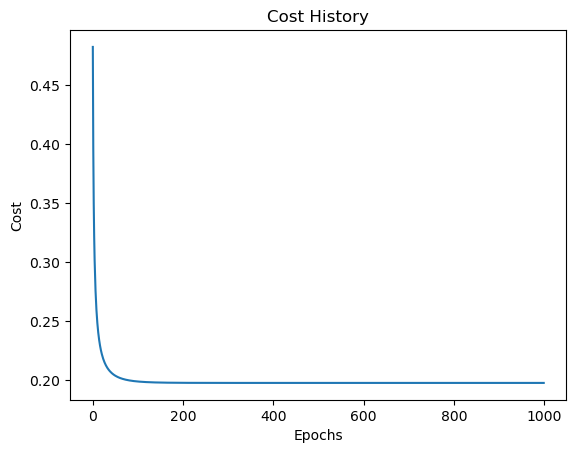

In [87]:
from sklearn.model_selection import train_test_split

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = np.hstack([np.ones((X_train.shape[0], 1)), X_train])

beta, cost_history = mini_batch_gradient_descent_logistic(X_train, y_train)

print(f"Weights: {beta}")
print("-" * 50)

fig, ax = plt.subplots()
ax.plot(cost_history)
ax.set(
    title="Cost History",
    ylabel="Cost",
    xlabel="Epochs"
)
plt.show()

> **Note:** To avoid overfitting it's a good practice to stop the learning of the model on the epoch 150 for example, We can see that after epoch 150 there is no meaningful improvement in the cost of the model and the model is overfitting to the data after this epoch and to make out model do better on the unseen data and generalize to the unseen data data well we should stop the training earlier.